## Part 1 — Load Cell Ranger output with Scanpy

Read 10x **gene expression** matrices produced by Cell Ranger (`filtered_feature_bc_matrix` / MTX) for each sample, merge objects, then run QC and Scanpy preprocessing (normalization, HVG, neighbors, UMAP, clustering, etc.).


In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context

In [2]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
# sc.settings.set_figure_params(dpi=300, facecolor="white")

/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.10.1 anndata==0.10.8 umap==0.5.6 numpy==1.26.4 scipy==1.13.0 pandas==2.0.3 scikit-learn==1.4.2 statsmodels==0.14.2 igraph==0.11.3 pynndescent==0.5.12


In [ ]:
import os

# Define sample IDs
samples = ["GW7", "GW12", "GW6", "GW9", "GW10", "GW16", "GW17", "GW20"]

# Paths to Cell Ranger RNA count matrices (filtered_feature_bc_matrix)
countsfiles = [
    os.path.join("/cluster/huanglab/lab/LabDataset/jiamao/HumanSpinalCord/ProcessData/Cellranger", sample, "outs/filtered_feature_bc_matrix/")
    for sample in samples[:2]
] + [
    os.path.join("/cluster/huanglab/lab/LabDataset/dhong/HumanSpinalCord/ProcessData/Cellranger", sample, "outs/filtered_feature_bc_matrix/")
    for sample in samples[2:]
]

print(countsfiles)

In [ ]:
data_list = []
for sample, file_path in zip(samples, countsfiles):
    # Load matrix
    adata = sc.read_10x_mtx(
        file_path,
        var_names="gene_symbols",
        cache=True,
    )
    adata.var_names_make_unique()
    adata.obs["Sample"] = sample
    
    # Collect per-sample AnnData
    data_list.append(adata)

In [ ]:
adata = data_list[0].concatenate(data_list[1:8])

In [ ]:
adata

In [ ]:
adata.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/1.hscAdata_raw.h5ad')

In [49]:
adata = sc.read('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/1.hscAdata_raw.h5ad')

In [50]:
adata

AnnData object with n_obs × n_vars = 107558 × 36601
    obs: 'Sample', 'batch'
    var: 'gene_ids', 'feature_types'

In [51]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [52]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

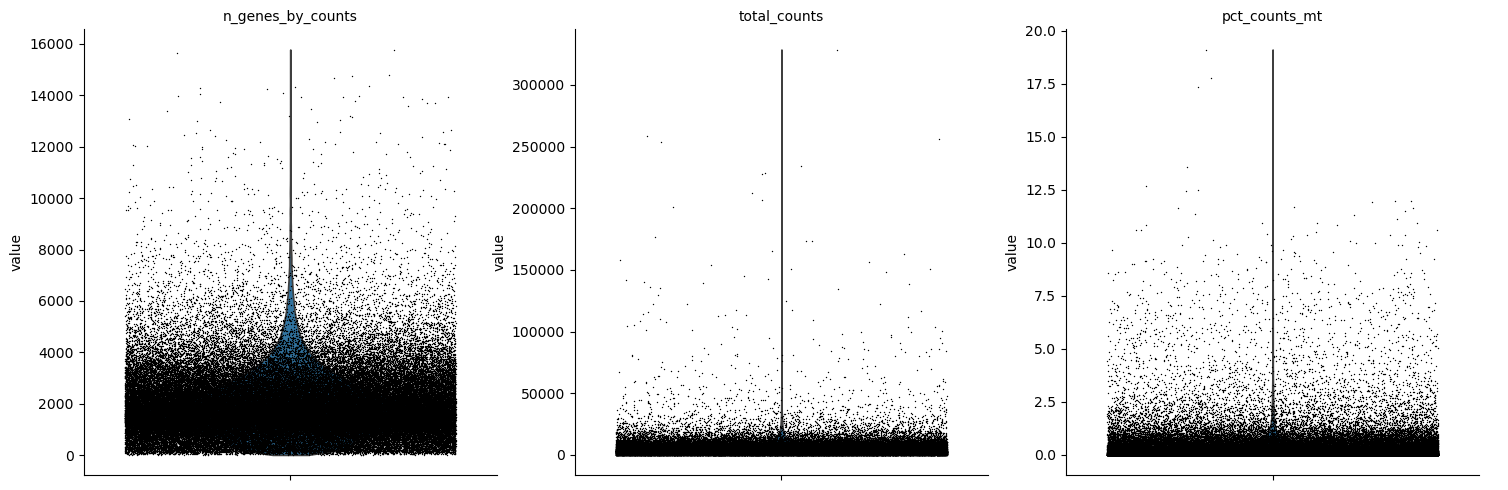

In [53]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

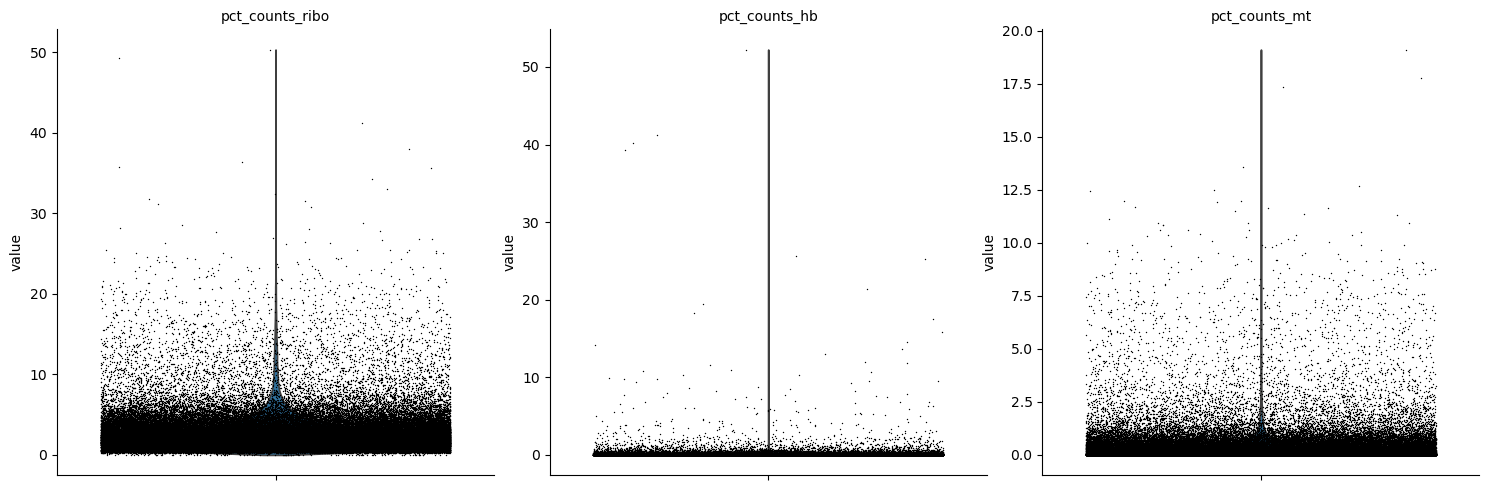

In [54]:
sc.pl.violin(
    adata,
    ["pct_counts_ribo", "pct_counts_hb", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

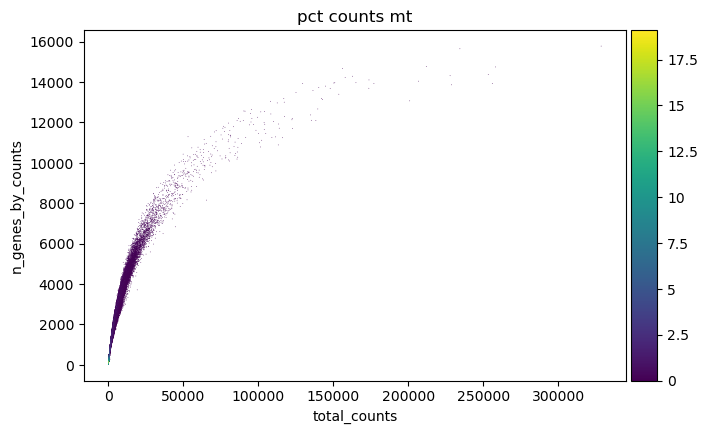

In [55]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [56]:
adata

AnnData object with n_obs × n_vars = 107558 × 36601
    obs: 'Sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [58]:
filtered_adata = adata[(adata.obs['pct_counts_mt'] < 5) &
(adata.obs['n_genes_by_counts'] >= 800) & 
(adata.obs['n_genes_by_counts'] <= 10000) & 
(adata.obs['total_counts'] >= 1000) & 
(adata.obs['total_counts'] <= 30000)].copy()
filtered_adata

AnnData object with n_obs × n_vars = 93089 × 36601
    obs: 'Sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [59]:
filtered_adata.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/2.hscAdata_filtered.h5ad')

In [24]:
filtered_adata = sc.read('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/2.hscAdata_filtered.h5ad')

In [60]:
filtered_adata

AnnData object with n_obs × n_vars = 93089 × 36601
    obs: 'Sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [61]:
filtered_adata.obs.to_csv("filtered_adata_obs.csv", index=True)

In [62]:
filtered_adata_proj = pd.read_csv('filtered_adata_proj_with_barcode.csv', index_col=0)
filtered_adata_proj

,Sample,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,barcode
AAACAGCCAACACTTG-1-0,GW7,0,3240,8.083637,7230,8.886132,20.304288,26.998617,35.394191,50.484094,3,1.386294,0.041494,138,4.934474,1.908714,1,0.693147,0.013831,GW7#AAACAGCCAACACTTG-1
AAACAGCCAGCAAGAT-1-0,GW7,0,2165,7.680637,3658,8.204946,15.992346,22.307272,31.492619,49.863313,1,0.693147,0.027337,120,4.795791,3.280481,0,0.000000,0.000000,GW7#AAACAGCCAGCAAGAT-1
AAACAGCCAGCAAGTG-1-0,GW7,0,1299,7.170120,2240,7.714677,23.571429,32.410714,43.973214,64.330357,1,0.693147,0.044643,32,3.496508,1.428572,1,0.693147,0.044643,GW7#AAACAGCCAGCAAGTG-1
AAACAGCCAGGCATCT-1-0,GW7,0,1178,7.072422,1863,7.530480,18.303811,27.053140,40.365003,63.607085,0,0.000000,0.000000,30,3.433987,1.610306,0,0.000000,0.000000,GW7#AAACAGCCAGGCATCT-1
AAACAGCCATAAAGCA-1-0,GW7,0,1935,7.568379,3393,8.129765,19.805482,27.674624,37.459475,55.938697,1,0.693147,0.029472,45,3.828641,1.326260,0,0.000000,0.000000,GW7#AAACAGCCATAAAGCA-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTTAGGACC-1-7,GW20,7,1632,7.398174,2818,7.944138,21.220724,28.672818,39.354152,59.829666,2,1.098612,0.070972,89,4.499810,3.158269,0,0.000000,0.000000,GW20#TTTGTTGGTTAGGACC-1
TTTGTTGGTTGCACAA-1-7,GW20,7,1784,7.487174,3318,8.107419,24.080772,31.314045,41.078963,59.885473,0,0.000000,0.000000,37,3.637586,1.115130,0,0.000000,0.000000,GW20#TTTGTTGGTTGCACAA-1
TTTGTTGGTTGCGGAT-1-7,GW20,7,1791,7.491088,2686,7.896181,15.115413,22.189129,32.278481,51.935964,4,1.609438,0.148920,38,3.663562,1.414743,2,1.098612,0.074460,GW20#TTTGTTGGTTGCGGAT-1
TTTGTTGGTTGGATCA-1-7,GW20,7,2045,7.623642,3636,8.198915,18.206821,25.687569,35.753575,54.620462,3,1.386294,0.082508,62,4.143135,1.705171,3,1.386294,0.082508,GW20#TTTGTTGGTTGGATCA-1


In [63]:
cell_names_to_select = filtered_adata_proj.index

In [64]:
adata = filtered_adata[cell_names_to_select]

In [65]:
adata

View of AnnData object with n_obs × n_vars = 86977 × 36601
    obs: 'Sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [66]:
adata.obs

,Sample,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
AAACAGCCAACACTTG-1-0,GW7,0,3240,8.083637,7230.0,8.886132,20.304288,26.998617,35.394191,50.484094,3.0,1.386294,0.041494,138.0,4.934474,1.908714,1.0,0.693147,0.013831
AAACAGCCAGCAAGAT-1-0,GW7,0,2165,7.680637,3658.0,8.204946,15.992346,22.307272,31.492619,49.863313,1.0,0.693147,0.027337,120.0,4.795791,3.280481,0.0,0.000000,0.000000
AAACAGCCAGCAAGTG-1-0,GW7,0,1299,7.170120,2240.0,7.714677,23.571429,32.410714,43.973214,64.330357,1.0,0.693147,0.044643,32.0,3.496508,1.428571,1.0,0.693147,0.044643
AAACAGCCAGGCATCT-1-0,GW7,0,1178,7.072422,1863.0,7.530480,18.303811,27.053140,40.365003,63.607085,0.0,0.000000,0.000000,30.0,3.433987,1.610306,0.0,0.000000,0.000000
AAACAGCCATAAAGCA-1-0,GW7,0,1935,7.568379,3393.0,8.129765,19.805482,27.674624,37.459475,55.938697,1.0,0.693147,0.029472,45.0,3.828641,1.326260,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTTAGGACC-1-7,GW20,7,1632,7.398174,2818.0,7.944138,21.220724,28.672818,39.354152,59.829666,2.0,1.098612,0.070972,89.0,4.499810,3.158268,0.0,0.000000,0.000000
TTTGTTGGTTGCACAA-1-7,GW20,7,1784,7.487174,3318.0,8.107419,24.080772,31.314045,41.078963,59.885473,0.0,0.000000,0.000000,37.0,3.637586,1.115130,0.0,0.000000,0.000000
TTTGTTGGTTGCGGAT-1-7,GW20,7,1791,7.491088,2686.0,7.896181,15.115413,22.189129,32.278481,51.935964,4.0,1.609438,0.148920,38.0,3.663562,1.414743,2.0,1.098612,0.074460
TTTGTTGGTTGGATCA-1-7,GW20,7,2045,7.623642,3636.0,8.198915,18.206821,25.687569,35.753575,54.620462,3.0,1.386294,0.082508,62.0,4.143135,1.705171,3.0,1.386294,0.082508


In [67]:
adata.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/3.hscAdata_Proj.h5ad')

## Exclude week-7 extra-spinal tissue

In [68]:
# Load saved CSV
gw7_ex_cells = pd.read_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/gw7_cluster_4_and_5_cells.csv')

# Cell indices to drop
gw7_ex_cells = gw7_ex_cells['cell_index'].tolist()

In [69]:
# Remove these cells from raw data
cells_to_keep = adata.obs.index.difference(gw7_ex_cells)
adata_filtered = adata[cells_to_keep]

In [70]:
adata_filtered

View of AnnData object with n_obs × n_vars = 82586 × 36601
    obs: 'Sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [71]:
adata_filtered.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/data/scMulti-omics/4.hscAdata_final.h5ad')

In [72]:
obs_stats = adata_filtered.obs

In [73]:
sample_stats = obs_df.groupby('Sample').agg(
    cell_count=('Sample', 'size'),
    n_genes_by_counts_median=('n_genes_by_counts', 'median'),
    total_counts_median=('total_counts', 'median')
).reset_index()

In [74]:
sample_stats

,Sample,cell_count,n_genes_by_counts_median,total_counts_median
0,GW6,14231,1576.0,2786.0
1,GW7,6136,2121.0,4054.5
2,GW9,9141,2172.0,4218.0
3,GW10,9635,2108.0,4146.0
4,GW12,10409,2134.0,4175.0
5,GW16,13854,1366.0,2239.0
6,GW17,7733,2660.0,6072.0
7,GW20,11570,1673.0,2963.5
